In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [4]:
df = pd.read_csv("Indian_Load_With_Synthetic_Weather.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df.reset_index(drop=True, inplace=True)

print(df.head())
print(df.tail())


   Year         Date  Hourly Demand Met (in MW)            Datetime  \
0  2024  01-Jan 12am                  140980.07 2024-01-01 00:00:00   
1  2024   01-Jan 1am                  137655.76 2024-01-01 01:00:00   
2  2024   01-Jan 2am                  135181.10 2024-01-01 02:00:00   
3  2024   01-Jan 3am                  134351.94 2024-01-01 03:00:00   
4  2024   01-Jan 4am                  137807.77 2024-01-01 04:00:00   

   Temperature_C  Humidity_%  
0          17.87       77.03  
1          18.45       72.02  
2          18.23       76.68  
3          18.10       71.82  
4          17.66       76.13  
       Year         Date  Hourly Demand Met (in MW)            Datetime  \
13123  2025   30-Jun 7pm                  200408.91 2025-06-30 19:00:00   
13124  2025   30-Jun 8pm                  206095.88 2025-06-30 20:00:00   
13125  2025   30-Jun 9pm                  205715.27 2025-06-30 21:00:00   
13126  2025  30-Jun 10pm                  205189.75 2025-06-30 22:00:00   
13127  2025 

In [5]:
FEATURES = ["Hourly Demand Met (in MW)", "Temperature_C", "Humidity_%"]
TARGET = "Hourly Demand Met (in MW)"

data = df[FEATURES]


In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [7]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # Load is column 0
    return np.array(X), np.array(y)

WINDOW_SIZE = 24

X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("Input shape:", X.shape)
print("Output shape:", y.shape)


Input shape: (13104, 24, 3)
Output shape: (13104,)


In [8]:
train_split_index = int(0.8 * len(X))

X_train, X_test = X[:train_split_index], X[train_split_index:]
y_train, y_test = y[:train_split_index], y[train_split_index:]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0091 - val_loss: 0.0018
Epoch 2/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 3/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 4/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 5/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.4075e-04 - val_loss: 6.7884e-04
Epoch 6/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.5161e-04 - val_loss: 7.0252e-04
Epoch 7/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 6.4811e-04 - val_loss: 6.7002e-04
Epoch 8/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 6.3220e-04 - val_loss: 0.0012
Epoch 9/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5.7814e-04 - val_loss: 6.9352e-04
Epoch 10/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5.7497e-04 - val_loss: 6.5445e-04
Epoch 11/15
590/590 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5.4525e-04 - val_loss: 7.426

In [10]:
predictions = model.predict(X_test)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [11]:
load_scaler = MinMaxScaler()
load_scaler.min_ = scaler.min_[0:1  ]
load_scaler.scale_ = scaler.scale_[0:1]

y_test_actual = load_scaler.inverse_transform(y_test.reshape(-1, 1))
pred_actual = load_scaler.inverse_transform(predictions)


In [12]:
mae = mean_absolute_error(y_test_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))

print(f"MAE  : {mae:.2f} MW")
print(f"RMSE : {rmse:.2f} MW")


MAE  : 2656.72 MW
RMSE : 3332.12 MW


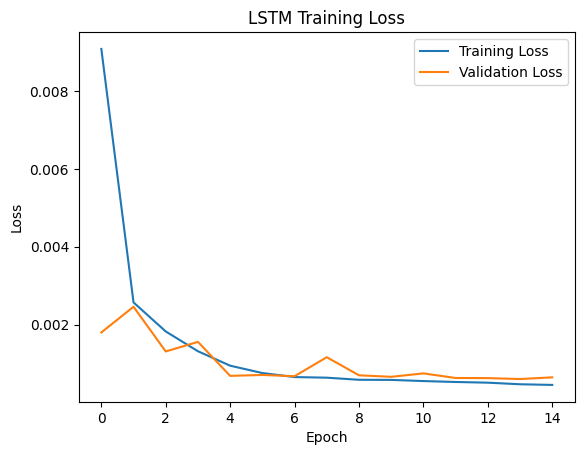

In [13]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


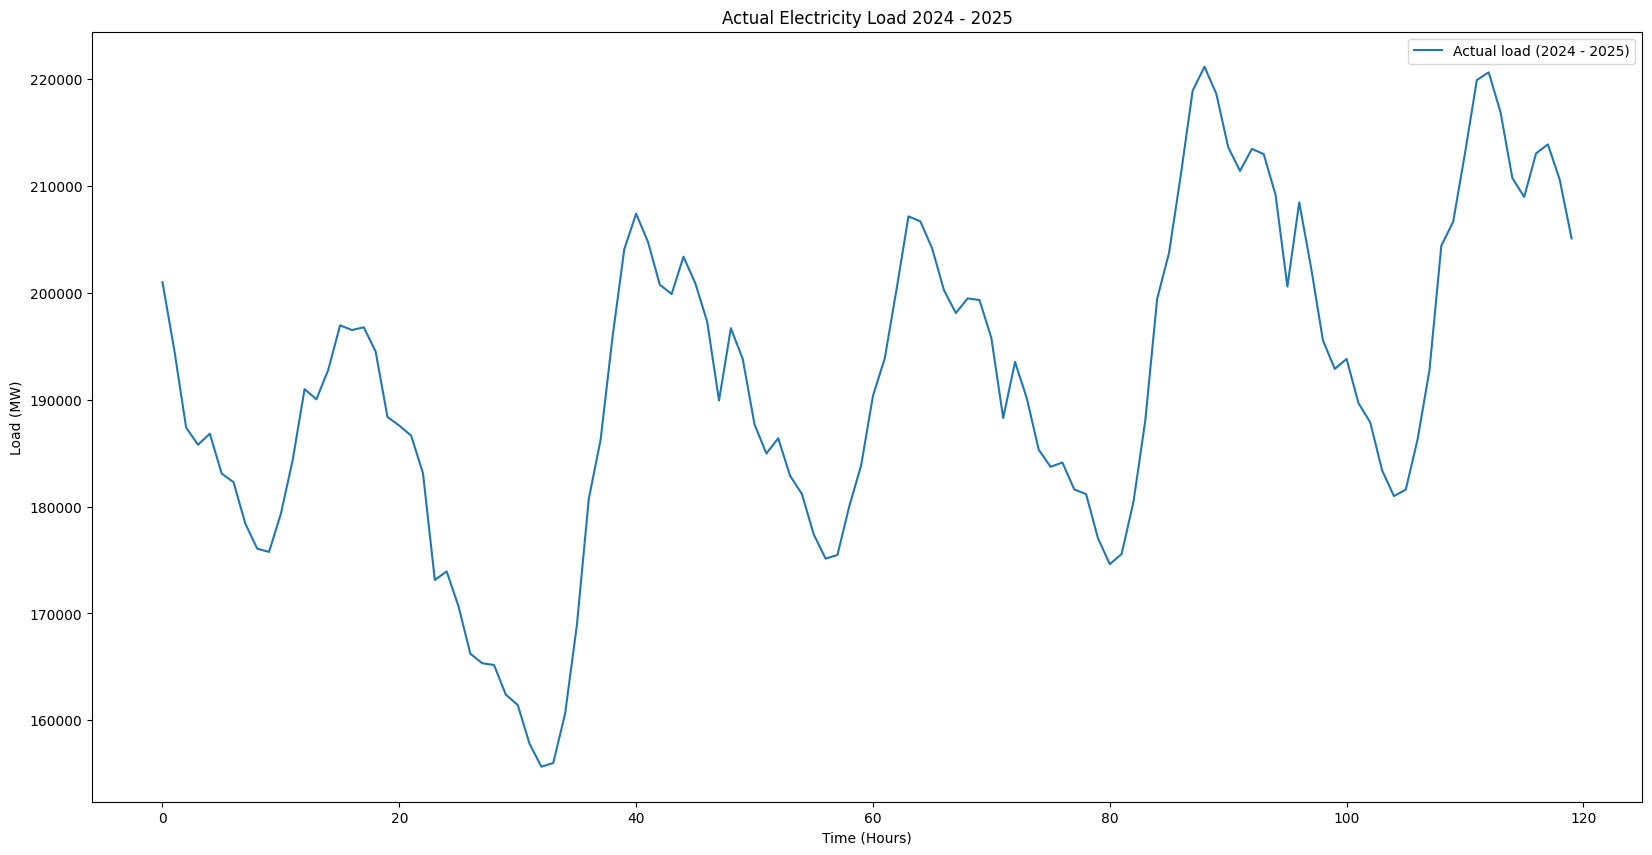

In [14]:
plt.figure(figsize=(20,10))
plt.plot(y_test_actual[:120], label="Actual load (2024 - 2025)")
plt.legend()
plt.title("Actual Electricity Load 2024 - 2025")
plt.xlabel("Time (Hours)")
plt.ylabel("Load (MW)")
plt.show()

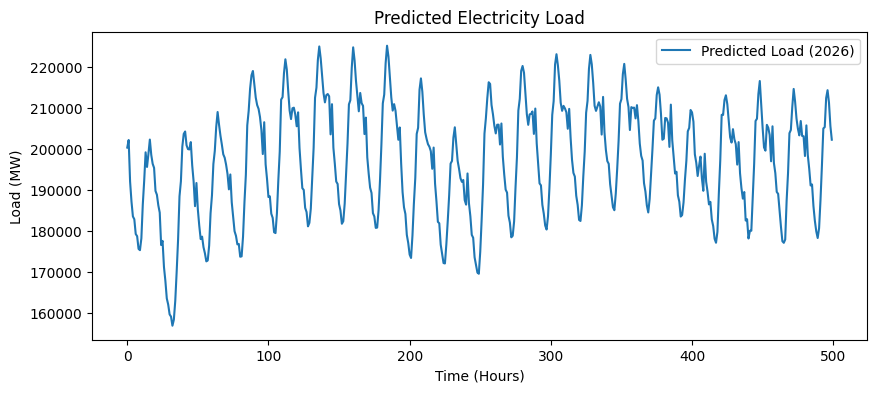

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(pred_actual[:500], label="Predicted Load (2026)")
plt.legend()
plt.title("Predicted Electricity Load 2026")
plt.xlabel("Time (Hours)")
plt.ylabel("Load (MW)")
plt.show()

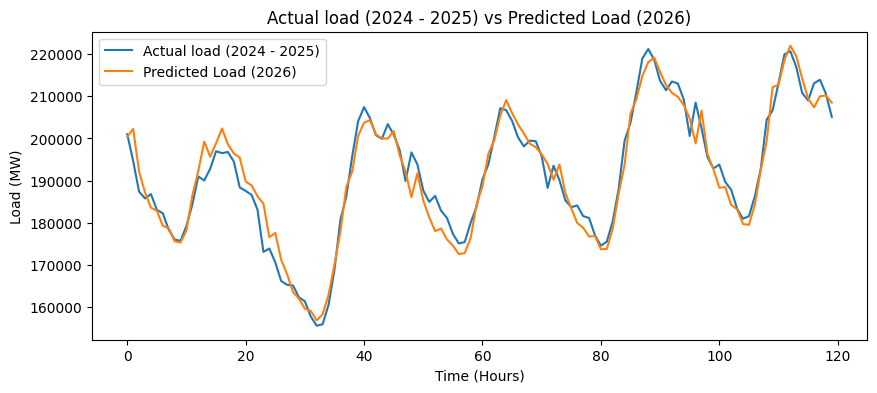

In [16]:
plt.figure(figsize=(10,4))
plt.plot(y_test_actual[:120], label="Actual load (2024 - 2025)")
plt.plot(pred_actual[:120], label="Predicted Load (2026)")
plt.legend()
plt.title("Actual load (2024 - 2025) vs Predicted Load (2026)")
plt.xlabel("Time (Hours)")
plt.ylabel("Load (MW)")
plt.show()


In [17]:
# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_actual - pred_actual) / y_test_actual)) * 100

accuracy_percent = 100 - mape

# print(f"MAPE     : {mape:.2f} %")
print(f"Accuracy : {accuracy_percent:.2f} %")


Accuracy : 98.68 %


In [18]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual Load (2024 - 2025) (MW)": y_test_actual.flatten(),
    "Predicted Load (2026) (MW)": pred_actual.flatten()
})

# Calculate error
# comparison_df["Error (MW)"] = comparison_df["Actual Load (2024 - 2025) (MW)"] - comparison_df["Predicted Load (2026) (MW)"]

# Format all values to exactly 2 decimal places
comparison_df["Actual Load (2024 - 2025) (MW)"] = comparison_df["Actual Load (2024 - 2025) (MW)"].map("{:.2f}".format)
comparison_df["Predicted Load (2026) (MW)"] = comparison_df["Predicted Load (2026) (MW)"].map("{:.2f}".format)
# comparison_df["Error (MW)"] = comparison_df["Error (MW)"].map("{:.2f}".format)

# Display first 20 rows
print("Actual load (2024 - 2025) vs Predicted Load (2026) (First 20 Samples):")
print(comparison_df.head(20))

# Display last 20 rows
print("\nActual load (2024 - 2025) vs Predicted Load (2026) (Last 20 Samples):")
print(comparison_df.tail(20))


Actual load (2024 - 2025) vs Predicted Load (2026) (First 20 Samples):
   Actual Load (2024 - 2025) (MW) Predicted Load (2026) (MW)
0                       200995.06                  200398.39
1                       194631.15                  202250.42
2                       187385.86                  192124.92
3                       185788.42                  187195.88
4                       186816.18                  183591.84
5                       183089.63                  182902.67
6                       182274.39                  179303.09
7                       178397.09                  178761.70
8                       176058.03                  175663.61
9                       175754.22                  175354.08
10                      179334.70                  178258.66
11                      184374.30                  186493.81
12                      190992.00                  192324.92
13                      190036.80                  199243.25
14            